In [71]:
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split   # split data
from sklearn.preprocessing import StandardScaler       # normalize features
from sklearn.svm import SVC                            # classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [72]:
normal_path = "../datasets/Normal"
vox_path = "../datasets/Vox senilis"

normal_files = [os.path.join(normal_path, f) for f in os.listdir(normal_path) if f.endswith(".wav")]
vox_files = [os.path.join(vox_path, f) for f in os.listdir(vox_path) if f.endswith(".wav")]

print("Normal files:", len(normal_files))
print("Vox senilis files:", len(vox_files))


Normal files: 560
Vox senilis files: 392


In [73]:


print("Normal folder exists:", os.path.exists("../datasets/Normal"))
print("Vox folder exists:", os.path.exists("../datasets/Vox senilis"))

print("Normal dir raw:", os.listdir("../datasets/Normal"))
print("Vox dir raw:", os.listdir("../datasets/Vox senilis"))


Normal folder exists: True
Vox folder exists: True
Normal dir raw: ['11-a_h-egg.wav', '11-a_h.wav', '11-a_l-egg.wav', '11-a_l.wav', '11-a_lhl-egg.wav', '11-a_lhl.wav', '11-a_n-egg.wav', '11-a_n.wav', '11-iau-egg.wav', '11-iau.wav', '11-i_h-egg.wav', '11-i_h.wav', '11-i_l-egg.wav', '11-i_l.wav', '11-i_lhl-egg.wav', '11-i_lhl.wav', '11-i_n-egg.wav', '11-i_n.wav', '11-phrase-egg.wav', '11-phrase.wav', '11-u_h-egg.wav', '11-u_h.wav', '11-u_l-egg.wav', '11-u_l.wav', '11-u_lhl-egg.wav', '11-u_lhl.wav', '11-u_n-egg.wav', '11-u_n.wav', '15-a_h-egg.wav', '15-a_h.wav', '15-a_l-egg.wav', '15-a_l.wav', '15-a_lhl-egg.wav', '15-a_lhl.wav', '15-a_n-egg.wav', '15-a_n.wav', '15-iau-egg.wav', '15-iau.wav', '15-i_h-egg.wav', '15-i_h.wav', '15-i_l-egg.wav', '15-i_l.wav', '15-i_lhl-egg.wav', '15-i_lhl.wav', '15-i_n-egg.wav', '15-i_n.wav', '15-phrase-egg.wav', '15-phrase.wav', '15-u_h-egg.wav', '15-u_h.wav', '15-u_l-egg.wav', '15-u_l.wav', '15-u_lhl-egg.wav', '15-u_lhl.wav', '15-u_n-egg.wav', '15-u_n.wav', 

In [74]:
def validate_files(file_list):
    valid_files = []

    for f in file_list:
        print("Checking:", f)
        audio, sr = librosa.load(f, sr=None)
        print("Loaded:", len(audio))

        if len(audio) > 0:
            valid_files.append(f)

    return valid_files


normal_files = validate_files(normal_files)
vox_files = validate_files(vox_files)

print("Normal files:", len(normal_files))
print("Vox files:", len(vox_files))

Checking: ../datasets/Normal\11-a_h-egg.wav
Loaded: 47046
Checking: ../datasets/Normal\11-a_h.wav
Loaded: 47046
Checking: ../datasets/Normal\11-a_l-egg.wav
Loaded: 51893
Checking: ../datasets/Normal\11-a_l.wav
Loaded: 51893
Checking: ../datasets/Normal\11-a_lhl-egg.wav
Loaded: 58957
Checking: ../datasets/Normal\11-a_lhl.wav
Loaded: 58957
Checking: ../datasets/Normal\11-a_n-egg.wav
Loaded: 55471
Checking: ../datasets/Normal\11-a_n.wav
Loaded: 55471
Checking: ../datasets/Normal\11-iau-egg.wav
Loaded: 1443631
Checking: ../datasets/Normal\11-iau.wav
Loaded: 1443631
Checking: ../datasets/Normal\11-i_h-egg.wav
Loaded: 43895
Checking: ../datasets/Normal\11-i_h.wav
Loaded: 43895
Checking: ../datasets/Normal\11-i_l-egg.wav
Loaded: 84064
Checking: ../datasets/Normal\11-i_l.wav
Loaded: 84064
Checking: ../datasets/Normal\11-i_lhl-egg.wav
Loaded: 72245
Checking: ../datasets/Normal\11-i_lhl.wav
Loaded: 72245
Checking: ../datasets/Normal\11-i_n-egg.wav
Loaded: 96751
Checking: ../datasets/Normal\11-i_

In [75]:
def extract_mfcc(file_path, n_mfcc=13):
    audio, sr = librosa.load(file_path, sr=None)
    
    # 2. Convert amplitudes to MFCC features
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)

    # 3. Average over time so every file becomes 13 numbers
    mfcc_mean = np.mean(mfcc.T, axis=0)

    return mfcc_mean

In [76]:
sample_file = normal_files[0]

features = extract_mfcc(sample_file, n_mfcc=13)

print("MFCC vector:", features)
print("Shape:", features.shape)


MFCC vector: [-156.14207     120.08645      36.928185     34.38947      20.46678
   18.525747     -0.7749013     7.2215        4.252459      9.618361
   -0.62279886    0.2562972     1.7512898 ]
Shape: (13,)


In [77]:
X = []
y = []

for file in normal_files:
    X.append(extract_mfcc(file))
    y.append(0)

for file in vox_files:
    X.append(extract_mfcc(file))
    y.append(1)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (952, 13)
y shape: (952,)


In [78]:
# train, test data splitting
# 80% training data
#20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing data:", X_test.shape[0])

Training samples: 761
Testing data: 191


In [79]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#scaler learns mean + std from training data

#applies same scaling to test data

In [80]:
model = SVC(kernel="rbf")
model.fit(X_train, y_train)
#fits the model


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [81]:
y_pred = model.predict(X_test)


In [82]:

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8743455497382199

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.92      0.90       112
           1       0.88      0.81      0.84        79

    accuracy                           0.87       191
   macro avg       0.87      0.86      0.87       191
weighted avg       0.87      0.87      0.87       191


Confusion Matrix:
 [[103   9]
 [ 15  64]]


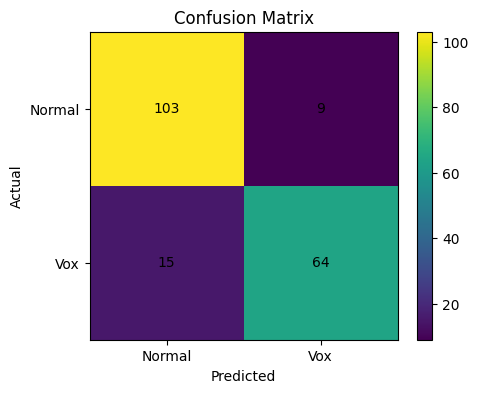

In [83]:
# plotiing confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Normal", "Vox"])
plt.yticks([0,1], ["Normal", "Vox"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [84]:
# testing unknown voice


unknown_audio = normal_files[0] 

features = extract_mfcc(unknown_audio)

# Reshape + scale using the SAME scaler
features = features.reshape(1, -1)
features = scaler.transform(features)

# Predict
pred = model.predict(features)

print("Raw prediction:", pred)

if pred[0] == 0:
    print("Result: Normal voice")
else:
    print("Result: Vox senilis")


Raw prediction: [0]
Result: Normal voice


In [85]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']